## Obtenção de Dados

Após consultas iniciais, identifiquei os dois principais mercados associados a essa eleição:

- id 522641 "South Korea First Lady Keon-hee arrested in 2025?"

Para análise, identifiquei a necessidade de obter os dados de probabilidade implícita e liquidez diária associada ao mercado. Filtrei para obter dados no ano de 2025, que é quando ocorreram as apostas. Obtive isso com a seguinte query:

```sql
WITH daily_trades AS (
  SELECT
    DATE(trade_timestamp) AS trade_date,
    nonusdc_side,
    price,
    usd_amount,
    ROW_NUMBER() OVER (
      PARTITION BY DATE(trade_timestamp), nonusdc_side 
      ORDER BY trade_timestamp DESC
    ) as rn
  FROM `even-continuity-441808-j0.polymarket_optimized.trades`
  WHERE market_id = '522641'
    -- Filtro de período 
    AND trade_timestamp < TIMESTAMP('2026-01-01 00:00:00')
    AND trade_timestamp >= TIMESTAMP('2024-12-01 00:00:00')
)
SELECT
  trade_date,
  -- Volume total negociado no dia (soma de todos os lados)
  SUM(usd_amount) AS total_daily_volume,
  
  -- Probabilidade Implícita baseada no Preço Médio Ponderado por Volume do token1 (Sim)
  SUM(CASE WHEN nonusdc_side = 'token1' THEN price * usd_amount ELSE 0 END) / 
  NULLIF(SUM(CASE WHEN nonusdc_side = 'token1' THEN usd_amount ELSE 0 END), 0) AS implied_prob_vwap_sim,
  
  -- Alternativa: Último preço do token1 (Sim) negociado no dia (Fechamento)
  MAX(CASE WHEN nonusdc_side = 'token1' AND rn = 1 THEN price END) AS implied_prob_last_sim

FROM daily_trades
GROUP BY trade_date
ORDER BY trade_date ASC;
```
Os resultados estão disponíveis no drive linkado no readme, com nome "sk_lady.csv"

## Análise inicial

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [45]:
df = pd.read_csv("./data/sk_lady.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 173 entries, 0 to 172
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   trade_date             173 non-null    str    
 1   total_daily_volume     173 non-null    float64
 2   implied_prob_vwap_sim  155 non-null    float64
 3   implied_prob_last_sim  155 non-null    float64
dtypes: float64(3), str(1)
memory usage: 5.5 KB


Os valores nulos do dataset correspondem a dias em que não houve nenhuma aposta/movimentação. Nesse caso, é razoável preenchê-los com a média dos valores adjacentes, pois não é provável que o valor tenha mudado muito se não houve compras.

In [46]:
df['implied_prob_vwap_sim'] =  df['implied_prob_vwap_sim'].interpolate(method='linear')
df['implied_prob_last_sim'] = df['implied_prob_last_sim'].interpolate(method='linear')
df.describe()

,total_daily_volume,implied_prob_vwap_sim,implied_prob_last_sim
count,173.000000,173.000000,173.000000
mean,3535.254335,0.725983,0.725855
std,8846.382026,0.157968,0.161401
min,0.550000,0.110000,0.110000
25%,203.800000,0.650000,0.650000
50%,1091.280000,0.744307,0.750000
75%,3309.910000,0.824620,0.820000
max,91562.810000,0.991182,0.999000


In [47]:
df["trade_date"] = pd.to_datetime(df["trade_date"])

<Axes: xlabel='trade_date', ylabel='total_daily_volume'>

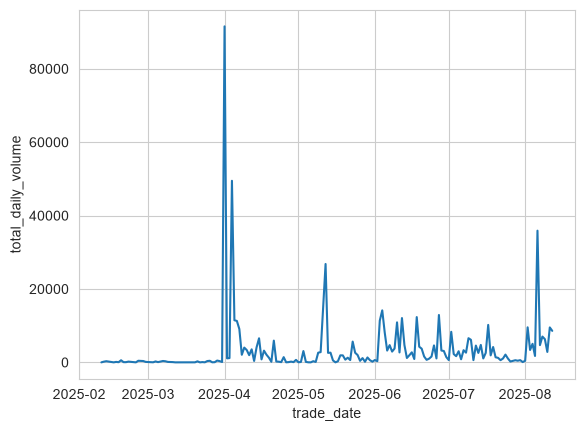

In [48]:
plt.figure(figsize=(12, 5))
sns.set_style("whitegrid")
sns.lineplot(data=df, x="trade_date", y="total_daily_volume", color="#2b5c8f", linewidth=2)
plt.title("Evolução Temporal do Volume Diário (South Korea First Lady)", fontsize=13, fontweight="bold")
plt.xlabel("Data de Negociação", fontsize=11)
plt.ylabel("Volume Diário (USD)", fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<Axes: xlabel='trade_date', ylabel='implied_prob_vwap_sim'>

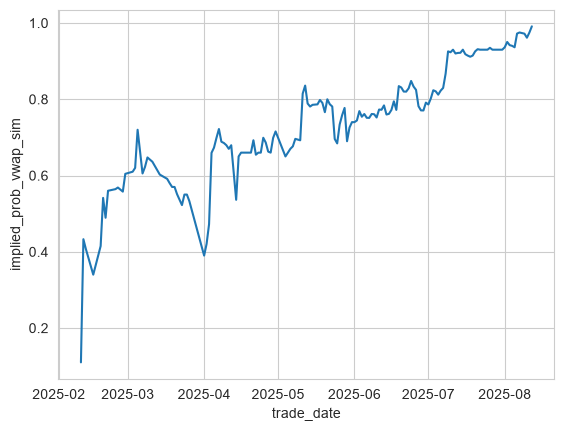

In [49]:
plt.figure(figsize=(12, 5))
sns.set_style("whitegrid")
sns.lineplot(data=df, x="trade_date", y="implied_prob_vwap_sim", color="#27ae60", linewidth=2)
plt.title("Evolução Temporal da Probabilidade Implícita (South Korea First Lady)", fontsize=13, fontweight="bold")
plt.xlabel("Data de Negociação", fontsize=11)
plt.ylabel("Probabilidade Implícita", fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

A probabilidade implícita converge para 1 no dia 12/08, que é justamente o dia da prisão da primeira-dama. Esse é um bom indício da integridade do dataset. Vemos alguns picos claros tanto no volume, quanto na probabilidade/preço. A seguir criarei alertas SQL mais formais, usando z-scores para detectar formalmente quais são os pontos anômalos.

## Alerta 1: Detectar Anomalia de Volume

```sql
WITH daily_agg AS (
  -- 1. Agrega o volume diário do mercado
  SELECT
    DATE(trade_timestamp) AS trade_date,
    SUM(usd_amount) AS total_daily_volume
  FROM `even-continuity-441808-j0.polymarket_optimized.trades`
  WHERE market_id = '522641'
    AND trade_timestamp >= TIMESTAMP('2025-01-01 00:00:00')
    AND trade_timestamp < TIMESTAMP('2026-01-01 00:00:00')
  GROUP BY trade_date
),
rolling_stats AS (
  -- 2. Aplica janela móvel de 7 dias para calcular Média e Desvio Padrão
  SELECT
    trade_date,
    total_daily_volume,
    AVG(total_daily_volume) OVER (
      ORDER BY trade_date 
      ROWS BETWEEN 7 PRECEDING AND 1 PRECEDING
    ) AS rolling_mean_vol,
    STDDEV(total_daily_volume) OVER (
      ORDER BY trade_date 
      ROWS BETWEEN 7 PRECEDING AND 1 PRECEDING
    ) AS rolling_std_vol
  FROM daily_agg
)
-- 3. Filtra apenas os dias que estouraram o limite estatístico (Z-score > 3)
SELECT
  trade_date,
  ROUND(total_daily_volume, 2) AS volume_do_dia,
  ROUND(rolling_mean_vol, 2) AS media_movel_7d,
  -- Calcula o Z-score do volume
  ROUND((total_daily_volume - rolling_mean_vol) / NULLIF(rolling_std_vol, 0), 2) AS z_score_volume,
  'ALERTA: Volume Anômalo / Pico de Negociação' AS tipo_alerta
FROM rolling_stats
WHERE (total_daily_volume - rolling_mean_vol) / NULLIF(rolling_std_vol, 0) > 3.0
ORDER BY trade_date DESC;
```

## Alerta 2: Detectar Anomalia de Preço


```sql
WITH daily_prices AS (
  -- 1. Pega o último preço do dia para o token "Sim" (token1)
  SELECT
    DATE(trade_timestamp) AS trade_date,
    price AS last_price,
    ROW_NUMBER() OVER (
      PARTITION BY DATE(trade_timestamp) 
      ORDER BY trade_timestamp DESC
    ) as rn
  FROM `even-continuity-441808-j0.polymarket_optimized.trades`
  WHERE market_id = '522641'
    AND nonusdc_side = 'token1'
    AND trade_timestamp >= TIMESTAMP('2025-01-01 00:00:00')
    AND trade_timestamp < TIMESTAMP('2026-01-01 00:00:00')
),
filtered_days AS (
  SELECT trade_date, last_price
  FROM daily_prices
  WHERE rn = 1
),
price_shifts AS (
  -- 2. Puxa o preço do dia anterior usando LAG()
  SELECT
    trade_date,
    last_price AS preco_atual,
    LAG(last_price, 1) OVER (ORDER BY trade_date) AS preco_dia_anterior
  FROM filtered_days
),
calculations AS (
  SELECT
    trade_date,
    preco_atual,
    preco_dia_anterior,
    (preco_atual - preco_dia_anterior) AS variacao_absoluta,
    SAFE_DIVIDE(preco_atual - preco_dia_anterior, preco_dia_anterior) * 100 AS variacao_percentual
  FROM price_shifts
)
-- 3. Dispara alerta se a probabilidade oscilou mais do que 25% de um dia para o outro
SELECT
  trade_date,
  ROUND(preco_dia_anterior * 100, 1) AS prob_ontem_pct,
  ROUND(preco_atual * 100, 1) AS prob_hoje_pct,
  ROUND(variacao_percentual, 1) as variacao_pct,
  'ALERTA: Mudança Brusca na Probabilidade Implícita' AS tipo_alerta
FROM calculations
WHERE ABS(variacao_percentual) >= 25.0 -- Limite de 25% de oscilação de um dia para o outro
  AND preco_dia_anterior IS NOT NULL
ORDER BY trade_date DESC;
```

## Visualização Integrada: Gráficos de Evolução de Volume e Preço com Alertas

Dividimos a visualização em dois gráficos dedicados:
1. **Evolução do Volume Diário:** Série temporal de `total_daily_volume` com marcação dos pontos de alerta de volume anômalo (`volume_sk.csv`).
2. **Evolução da Probabilidade Implícita (Preço):** Série temporal de `implied_prob_vwap_sim` com marcação dos pontos de alerta de variação brusca de preço (`preco_sk.csv`).

In [50]:
# Carregamento dos dados dos alertas
df_preco = pd.read_csv("./data/preco_sk.csv")
df_vol = pd.read_csv("./data/volume_sk.csv")

# Conversão das colunas de data para datetime
df_preco["trade_date"] = pd.to_datetime(df_preco["trade_date"])
df_vol["trade_date"] = pd.to_datetime(df_vol["trade_date"])

# Identificação dos registros correspondentes em sk_lady
df_alertas_vol = df[df["trade_date"].isin(df_vol["trade_date"])]
df_alertas_preco = df[df["trade_date"].isin(df_preco["trade_date"])]

### 1. Gráfico de Evolução do Volume com Alertas de Volume Anômalo

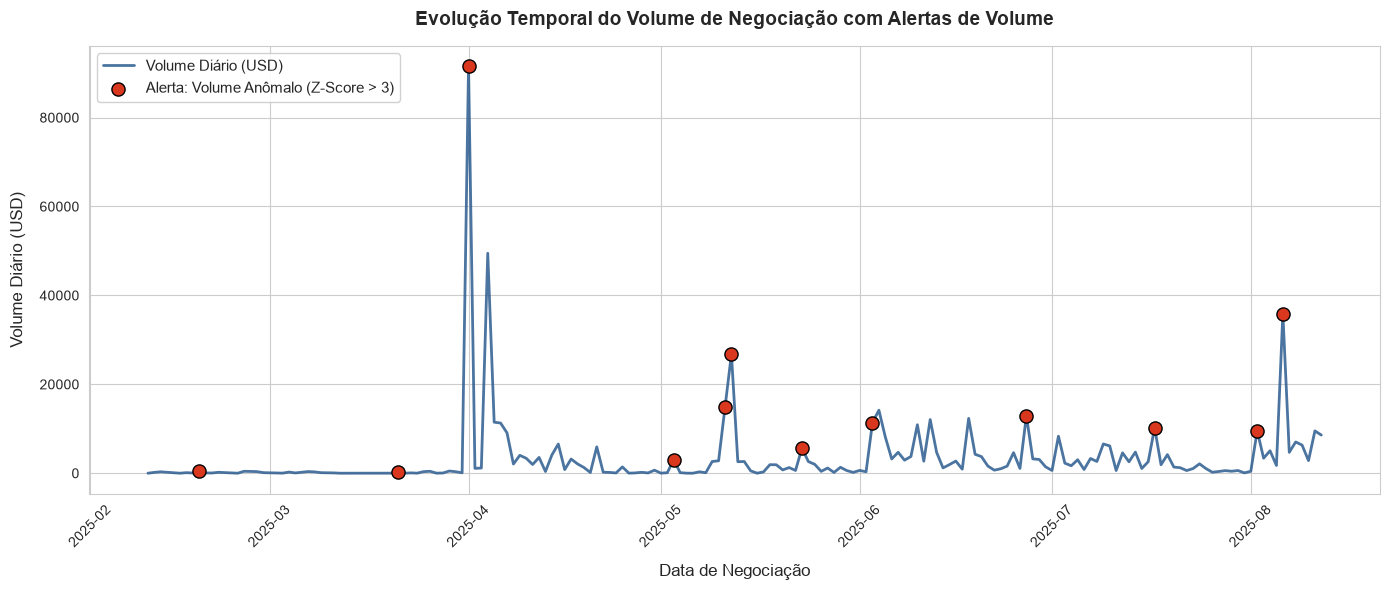

In [51]:
# Gráfico 1: Evolução do Volume e Alertas de Volume
plt.figure(figsize=(14, 6))
sns.set_style("whitegrid")

# Linha de volume diário
plt.plot(df["trade_date"], df["total_daily_volume"], color="#2b5c8f", linewidth=2, label="Volume Diário (USD)", alpha=0.85)

# Alertas de Volume Anômalo
plt.scatter(
    df_alertas_vol["trade_date"], 
    df_alertas_vol["total_daily_volume"], 
    color="#d9381e", 
    s=90, 
    zorder=5, 
    marker="o", 
    edgecolors="black", 
    linewidth=1,
    label="Alerta: Volume Anômalo (Z-Score > 3)"
)

# Configurações do gráfico
plt.title("Evolução Temporal do Volume de Negociação com Alertas de Volume", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Data de Negociação", fontsize=12, labelpad=10)
plt.ylabel("Volume Diário (USD)", fontsize=12, labelpad=10)
plt.xticks(rotation=45)
plt.legend(fontsize=11, loc="upper left", frameon=True, facecolor="white", framealpha=0.9)
plt.tight_layout()

plt.show()

### 2. Gráfico de Evolução da Probabilidade Implícita (Preço) com Alertas de Preço

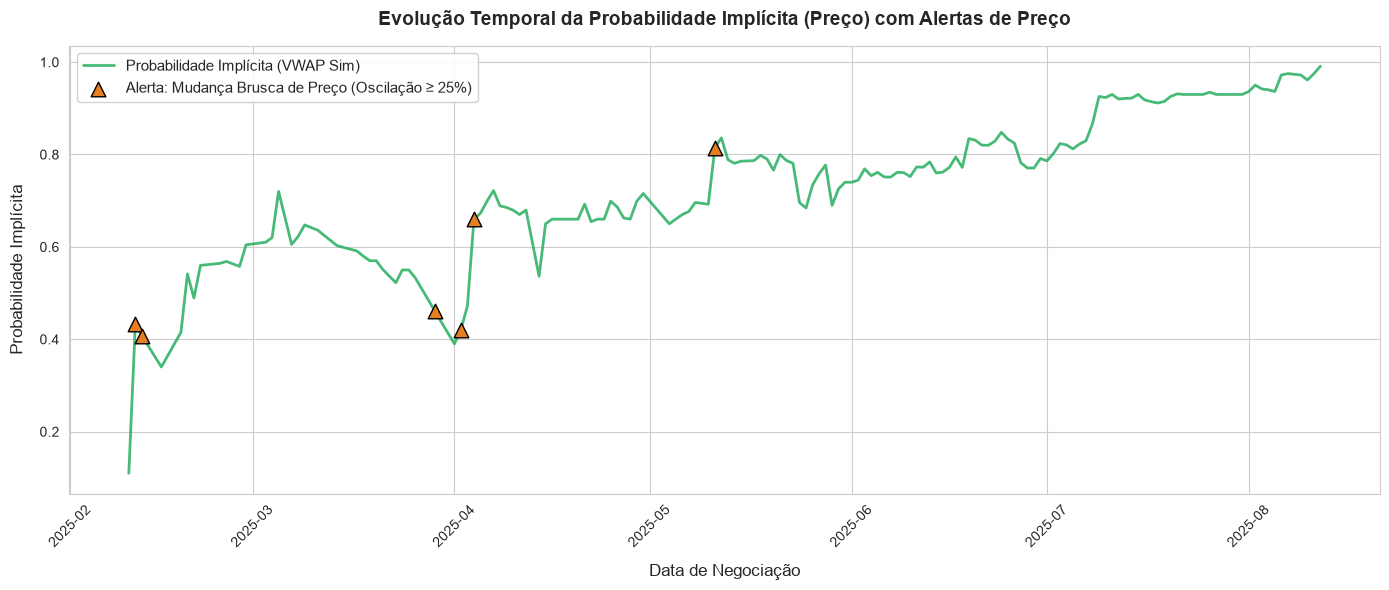

In [52]:
# Gráfico 2: Evolução da Probabilidade Implícita (Preço) e Alertas de Preço
plt.figure(figsize=(14, 6))
sns.set_style("whitegrid")

# Linha da probabilidade implícita
plt.plot(df["trade_date"], df["implied_prob_vwap_sim"], color="#27ae60", linewidth=2, label="Probabilidade Implícita (VWAP Sim)", alpha=0.85)

# Alertas de Mudança Brusca de Preço
plt.scatter(
    df_alertas_preco["trade_date"], 
    df_alertas_preco["implied_prob_vwap_sim"], 
    color="#e67e22", 
    s=110, 
    zorder=5, 
    marker="^", 
    edgecolors="black", 
    linewidth=1,
    label="Alerta: Mudança Brusca de Preço (Oscilação ≥ 25%)"
)

# Configurações do gráfico
plt.title("Evolução Temporal da Probabilidade Implícita (Preço) com Alertas de Preço", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Data de Negociação", fontsize=12, labelpad=10)
plt.ylabel("Probabilidade Implícita", fontsize=12, labelpad=10)
plt.xticks(rotation=45)
plt.legend(fontsize=11, loc="upper left", frameon=True, facecolor="white", framealpha=0.9)
plt.tight_layout()

plt.show()

Avaliando os pontos de disparo dos alertas e fazendo pesquisa sobre os acontecimentos, verifica-se que de fato os alertas disparados e picos observados são em pontos importantes! Por exemplo, o início de abril é quando ocorreu o impeachment do marido dela. Nesse ponto houve um pico massivo de volume e a probabilidade implícita, que vinha apresentando queda significativa, teve grande alta. Em meados de maio, outro momento de subida da probabilidade e pico de volume, foi o período de campanha e debates eleitorais para as eleições emergenciais, onde o candidato da oposição enfatizou que fortaleceria as investigações contra a primeira-dama em caso de eleição. No início de junho, outro grande pico de volume, foi quando ocorreram as eleições para substituí-lo, com vitória da oposição. Outro grande momento de volume foi dias antes da condenação, quando o resultado estava quase certo. De maneira geral, verificamos como o movimento do mercado acompanhou os eventos reais.

## Generalização: O Case Kanye West

Para avaliar a efetividade do alerta, vamos aplicá-lo em outro mercado semelhante: O que se perguntava se Kanye West seria preso em 2025. As consultas e alertas usados para esse mercado foram precisamente os mesmos dos usados para o da primeira-dama, mas com o id de mercado 539997, e estão disponíveis no drive. Observa-se a presença de alertas de volume e de preço ao longo do período, capturando momentos de volatilidade no mercado.

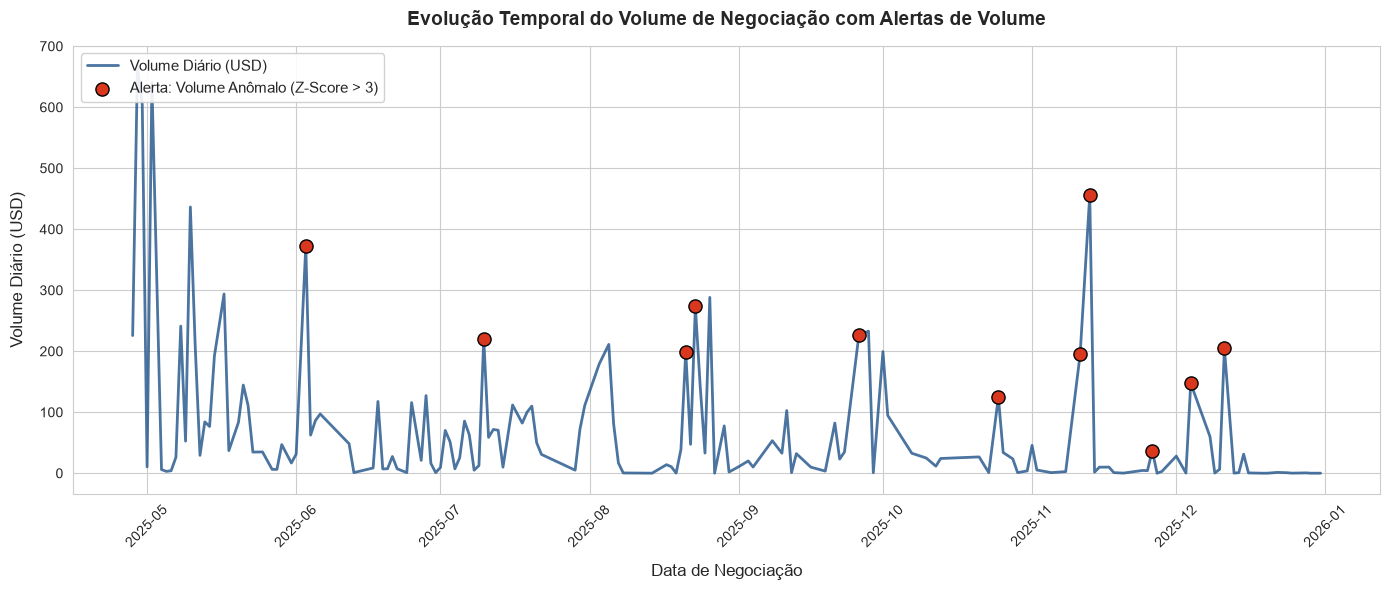

In [56]:
df = pd.read_csv("./data/kanye.csv")
df['implied_prob_vwap_sim'] =  df['implied_prob_vwap_sim'].interpolate(method='linear')
df['implied_prob_last_sim'] = df['implied_prob_last_sim'].interpolate(method='linear')
df["trade_date"] = pd.to_datetime(df["trade_date"])

df_preco = pd.read_csv("./data/preco_kanye.csv")
df_vol = pd.read_csv("./data/volume_kanye.csv")

# Conversão das colunas de data para datetime
df_preco["trade_date"] = pd.to_datetime(df_preco["trade_date"])
df_vol["trade_date"] = pd.to_datetime(df_vol["trade_date"])

# Identificação dos registros correspondentes em kanye
df_alertas_vol = df[df["trade_date"].isin(df_vol["trade_date"])]
df_alertas_preco = df[df["trade_date"].isin(df_preco["trade_date"])]

# Gráfico 1: Evolução do Volume e Alertas de Volume - Case Kanye West
plt.figure(figsize=(14, 6))
sns.set_style("whitegrid")

# Linha de volume diário
plt.plot(df["trade_date"], df["total_daily_volume"], color="#2b5c8f", linewidth=2, label="Volume Diário (USD)", alpha=0.85)

# Alertas de Volume Anômalo
plt.scatter(
    df_alertas_vol["trade_date"], 
    df_alertas_vol["total_daily_volume"], 
    color="#d9381e", 
    s=90, 
    zorder=5, 
    marker="o", 
    edgecolors="black", 
    linewidth=1,
    label="Alerta: Volume Anômalo (Z-Score > 3)"
)

# Configurações do gráfico
plt.title("Evolução Temporal do Volume de Negociação (Case Kanye West) com Alertas de Volume", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Data de Negociação", fontsize=12, labelpad=10)
plt.ylabel("Volume Diário (USD)", fontsize=12, labelpad=10)
plt.xticks(rotation=45)
plt.legend(fontsize=11, loc="upper left", frameon=True, facecolor="white", framealpha=0.9)
plt.tight_layout()

plt.show()

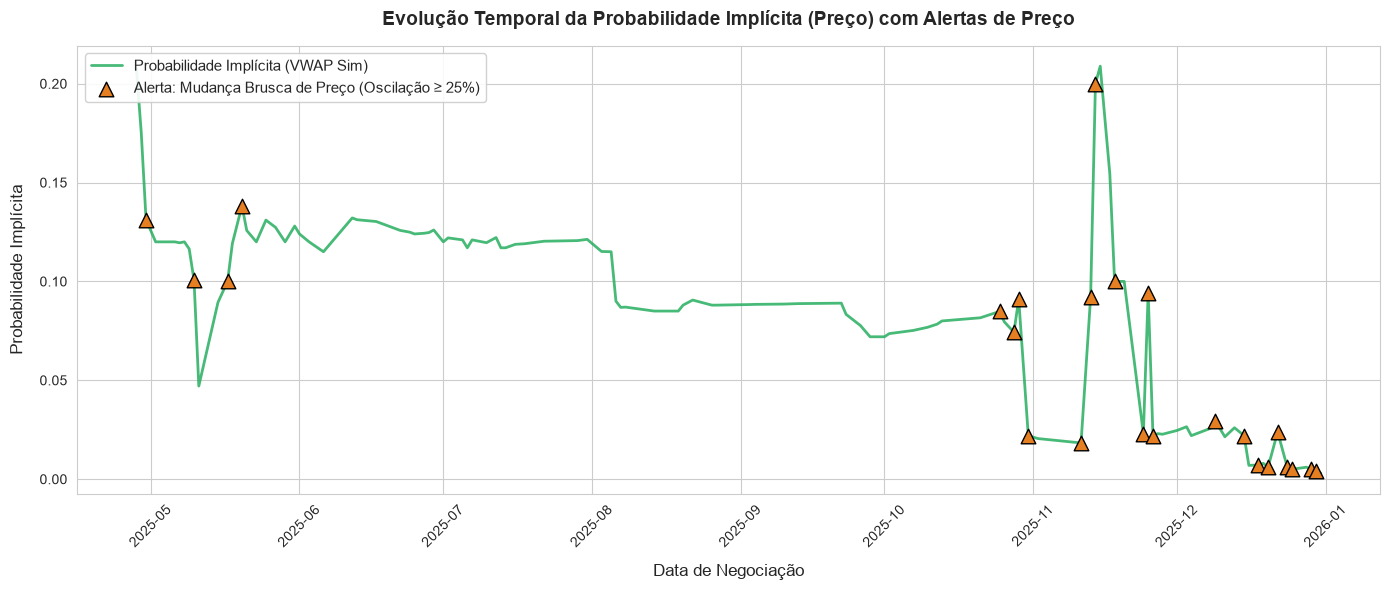

In [57]:
# Gráfico 2: Evolução da Probabilidade Implícita (Preço) e Alertas de Preço - Case Kanye West
plt.figure(figsize=(14, 6))
sns.set_style("whitegrid")

# Linha da probabilidade implícita
plt.plot(df["trade_date"], df["implied_prob_vwap_sim"], color="#27ae60", linewidth=2, label="Probabilidade Implícita (VWAP Sim)", alpha=0.85)

# Alertas de Mudança Brusca de Preço
plt.scatter(
    df_alertas_preco["trade_date"], 
    df_alertas_preco["implied_prob_vwap_sim"], 
    color="#e67e22", 
    s=110, 
    zorder=5, 
    marker="^", 
    edgecolors="black", 
    linewidth=1,
    label="Alerta: Mudança Brusca de Preço (Oscilação ≥ 25%)"
)

# Configurações do gráfico
plt.title("Evolução Temporal da Probabilidade Implícita - Case Kanye West (com Alertas de Preço)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Data de Negociação", fontsize=12, labelpad=10)
plt.ylabel("Probabilidade Implícita", fontsize=12, labelpad=10)
plt.xticks(rotation=45)
plt.legend(fontsize=11, loc="upper left", frameon=True, facecolor="white", framealpha=0.9)
plt.tight_layout()

plt.show()

Aqui vemos um grande pico de volume e probabilidade por volta de novembro, que foi justamente quando o Ministério Público recomendou a prisão em caso de falas apologéticas ao nazismo em show que faria em São Paulo, que acabou sendo cancelado e assim o preço caiu novamente. Assim, vemos como os alertas desenvolvidos são capazes de identificar acontecimentos do mundo real que levam a grandes mudanças nos mercados.